<div style='text-align: center; padding: 30px'>
  <h1><strong>Visualization of the Weigths</strong></h1>
  <h3><strong>Heriberto Espino Montelongo</strong></h1>
</div>

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches


In [16]:
classification = {
    'BTC': 'Mayor Cap. Mercado',
    'ETH': 'Mayor Cap. Mercado',
    'USDT': 'Stablecoins',
    'BNB': 'Mayor Cap. Mercado',
    'USDC': 'Stablecoins',
    'XRP': 'Mayor Cap. Mercado',
    'ADA': 'Mayor Cap. Mercado',
    'SOL': 'Mayor Cap. Mercado',
    'DOGE': 'Memecoins',
    'DAI': 'Stablecoins',
    'TRX': 'Tokens Blockchain',
    'TON': 'Tokens Blockchain',
    'MATIC': 'Tokens Blockchain',
    'DOT': 'Tokens Blockchain',
    'AVAX': 'Tokens Blockchain',
    'STETH': 'Tokens Blockchain',
    'WSTETH': 'Activos Envueltos',
    'SUI': 'Tokens Blockchain',
    'WBTC': 'Activos Envueltos',
    'WTRX': 'Activos Envueltos',
    'LTC': 'Pagos & DeFi',
    'LINK': 'Pagos & DeFi',
    'XLM': 'Pagos & DeFi',
    'HBAR': 'Pagos & DeFi',
    'BCH': 'Pagos & DeFi',
    'SHIB': 'Memecoins',
    'LEO': 'Tokens de Exchange'
}



In [17]:
weights_buy = pd.read_csv('portfolio-buy.csv')
weights_cfd = pd.read_csv('portfolio-cfd.csv')

In [18]:
# Transpose the dataframe to have features as rows
weights_buy_transposed = weights_buy.T.reset_index()
weights_buy_transposed.columns = ['feature', 'weight']

# Filter out the weights that are 0
weights_buy_transposed = weights_buy_transposed[weights_buy_transposed['weight'] != 0]

/tmp/ipykernel_7992/1956714746.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot_buy = sns.barplot(x='feature', y='weight', data=weights_buy_transposed, palette=weights_buy_transposed['category'].map(palette_buy).tolist(), alpha=0.9)


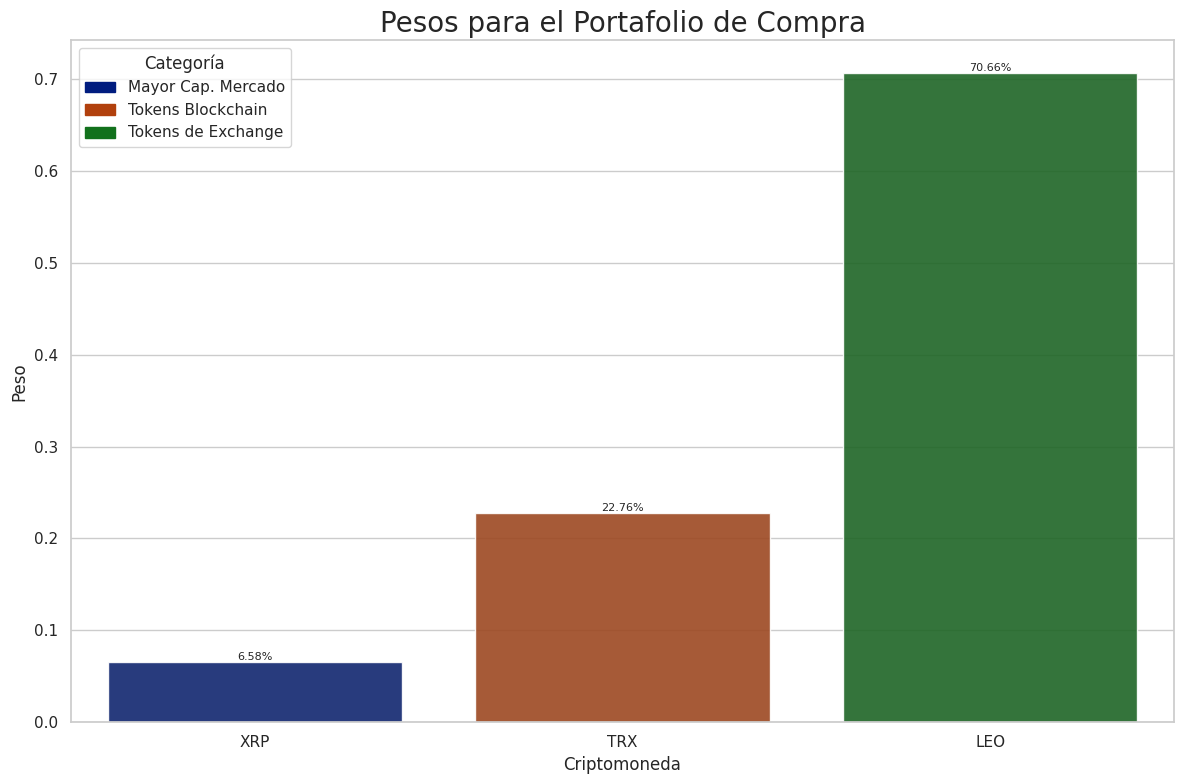

In [23]:
# Normalize the weights to make them add up to 1
weights_buy_transposed['weight'] = weights_buy_transposed['weight'] / weights_buy_transposed['weight'].abs().sum()

# Map each feature to its category
weights_buy_transposed['category'] = weights_buy_transposed['feature'].map(classification)

# Sort them by the category
weights_buy_transposed = weights_buy_transposed.sort_values(by='category', ascending=True)

# Define a color palette for the categories using seaborn
unique_categories_buy = weights_buy_transposed['category'].unique()
palette_buy = dict(zip(unique_categories_buy, sns.color_palette('dark', len(unique_categories_buy))))

# Plot the weights of the Buy model with colors based on the category
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")
barplot_buy = sns.barplot(x='feature', y='weight', data=weights_buy_transposed, palette=weights_buy_transposed['category'].map(palette_buy).tolist(), alpha=0.9)

# Add annotations
for p in barplot_buy.patches:
    barplot_buy.annotate(f'{p.get_height():.2%}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom' if p.get_height() > 0 else 'top', 
                         fontsize=8)

# Create legend
handles_buy = [mpatches.Patch(color=color, label=label) for label, color in palette_buy.items()]
plt.legend(title='Categoría', handles=handles_buy)

plt.title('Pesos para el Portafolio de Compra', fontsize=20)
plt.xlabel('Criptomoneda', fontsize=12)
plt.ylabel('Peso', fontsize=12)
plt.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('svg/02-pesos-buy.svg', format='svg', bbox_inches='tight')
plt.show()

np.float64(4.55232)

/tmp/ipykernel_7992/588087602.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='feature', y='weight', data=weights_cfd_transposed, palette=weights_cfd_transposed['category'].map(palette).tolist(), alpha=0.9)


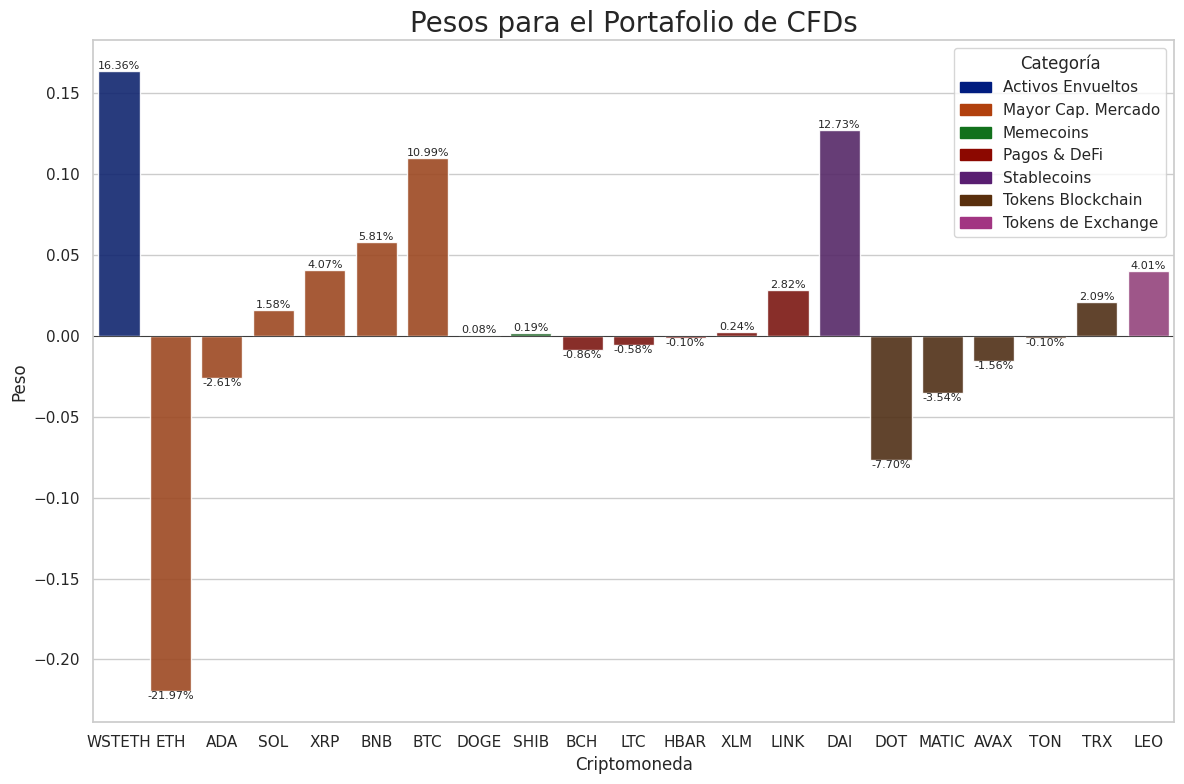

In [22]:
weights_cfd_transposed = weights_cfd.T.reset_index()
weights_cfd_transposed.columns = ['feature', 'weight']

weights_cfd_transposed = weights_cfd_transposed[weights_cfd_transposed['weight'] != 0]

# Normalize the weights to make them add up to 1
weights_cfd_transposed['weight'] = weights_cfd_transposed['weight'] / weights_cfd_transposed['weight'].abs().sum()

# Map each feature to its category
weights_cfd_transposed['category'] = weights_cfd_transposed['feature'].map(classification)

# Sort by category and then by weight within each category
weights_cfd_transposed = weights_cfd_transposed.sort_values(by=['category', 'weight'], ascending=[True, True])

# Define a color palette for the categories using seaborn
unique_categories = weights_cfd_transposed['category'].unique()
palette = dict(zip(unique_categories, sns.color_palette('dark', len(unique_categories))))

# Plot the weights of the CFD model with colors based on the category
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")
barplot = sns.barplot(x='feature', y='weight', data=weights_cfd_transposed, palette=weights_cfd_transposed['category'].map(palette).tolist(), alpha=0.9)


# Add annotations
for p in barplot.patches:
    barplot.annotate(f'{p.get_height():.2%}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom' if p.get_height() > 0 else 'top', 
                     fontsize=8)
    
# Create legend
handles = [mpatches.Patch(color=color, label=label) for label, color in palette.items()]
plt.legend(title='Categoría', handles=handles)

plt.title('Pesos para el Portafolio de CFDs', fontsize=20)
plt.xlabel('Criptomoneda', fontsize=12)
plt.ylabel('Peso', fontsize=12)
plt.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('svg/02-pesos-cfd.svg', format='svg', bbox_inches='tight')
plt.show()